In [1]:
import pandas as pd

In [3]:
data = pd.read_csv("Loan_risk.csv")

In [55]:
data.head()

,ApplicationDate,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,...,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
0,2018-01-01,45,39948,617,Employed,Master,22,13152,48,Married,...,3329.0,7.249.720.460.524.030,11,126928,19.965.200.000.000.000,22.758.963.035.547.000,4.198.059.915.607.370,18.107.719.782.539.400,0,49.0
1,2018-01-02,38,39709,628,Employed,Associate,15,26045,48,Single,...,33.090.833.333.333.300,9.351.320.992.549.320,3,43609,207.045,2.010.771.214.969.360,7.940.542.382.198.960,3.898.524.480.253.530,0,52.0
2,2018-01-03,47,40724,570,Employed,Bachelor,26,17627,36,Married,...,33.936.666.666.666.600,8.722.406.105.782.900,6,5205,21.762.700.000.000.000,21.254.800.984.525.700,6.664.066.876.774.690,4.621.569.652.325.320,0,52.0
3,2018-01-04,58,69084,545,Employed,High School,34,37898,96,Single,...,5757.0,8.961.547.069.636.460,5,99452,300.398,3.009.108.491.496.010,10.475.069.802.292.900,3.130.983.116.604.640,0,54.0
4,2018-01-05,37,103264,594,Employed,Associate,17,9184,36,Married,...,8.605.333.333.333.330,9.413.687.393.229.140,5,227019,197.184,17.599.017.877.532.800,33.017.914.048.482.300,7.020.984.743.780.870,1,36.0


In [56]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 36 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   ApplicationDate             20000 non-null  object
 1   Age                         20000 non-null  int64 
 2   AnnualIncome                20000 non-null  int64 
 3   CreditScore                 20000 non-null  int64 
 4   EmploymentStatus            20000 non-null  object
 5   EducationLevel              20000 non-null  object
 6   Experience                  20000 non-null  int64 
 7   LoanAmount                  20000 non-null  int64 
 8   LoanDuration                20000 non-null  int64 
 9   MaritalStatus               20000 non-null  object
 10  NumberOfDependents          20000 non-null  int64 
 11  HomeOwnershipStatus         20000 non-null  object
 12  MonthlyDebtPayments         20000 non-null  int64 
 13  CreditCardUtilizationRate   20000 non-null  ob

In [57]:
check_columns = ["Age", "AnnualIncome", "CreditScore", "LoanAmount", "LoanDuration","EmploymentStatus", "EducationLevel", "MaritalStatus", "Experience", "NumberOfDependents","HomeOwnershipStatus", "MonthlyDebtPayments","NumberOfOpenCreditLines","DebtToIncomeRatio","BankruptcyHistory","PreviousLoanDefaults","TotalAssets","TotalLiabilities","NetWorth","RiskScore"]

In [58]:
data_analysis = data[check_columns].copy()

In [59]:
data_analysis.head()

,Age,AnnualIncome,CreditScore,LoanAmount,LoanDuration,EmploymentStatus,EducationLevel,MaritalStatus,Experience,NumberOfDependents,HomeOwnershipStatus,MonthlyDebtPayments,NumberOfOpenCreditLines,DebtToIncomeRatio,BankruptcyHistory,PreviousLoanDefaults,TotalAssets,TotalLiabilities,NetWorth,RiskScore
0,45,39948,617,13152,48,Employed,Master,Married,22,2,Own,183,1,35.833.559.969.819.100,0,0,146111,19183,126928,49.0
1,38,39709,628,26045,48,Employed,Associate,Single,15,1,Mortgage,496,5,330.273.669.928.854,0,0,53204,9595,43609,52.0
2,47,40724,570,17627,36,Employed,Bachelor,Married,26,2,Rent,902,2,24.472.910.913.284.900,0,0,25176,128874,5205,52.0
3,58,69084,545,37898,96,Employed,High School,Single,34,1,Mortgage,755,2,4.362.442.650.682.680,0,0,104822,5370,99452,54.0
4,37,103264,594,9184,36,Employed,Associate,Married,17,1,Mortgage,274,0,788.842.122.687.955,0,0,244305,17286,227019,36.0


In [60]:
data_analysis = data_analysis.dropna()

In [61]:
data_analysis.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Age                      20000 non-null  int64 
 1   AnnualIncome             20000 non-null  int64 
 2   CreditScore              20000 non-null  int64 
 3   LoanAmount               20000 non-null  int64 
 4   LoanDuration             20000 non-null  int64 
 5   EmploymentStatus         20000 non-null  object
 6   EducationLevel           20000 non-null  object
 7   MaritalStatus            20000 non-null  object
 8   Experience               20000 non-null  int64 
 9   NumberOfDependents       20000 non-null  int64 
 10  HomeOwnershipStatus      20000 non-null  object
 11  MonthlyDebtPayments      20000 non-null  int64 
 12  NumberOfOpenCreditLines  20000 non-null  int64 
 13  DebtToIncomeRatio        20000 non-null  object
 14  BankruptcyHistory        20000 non-nul

In [62]:
data_analysis["DebtToIncomeRatio"] = data_analysis["DebtToIncomeRatio"].apply(lambda x: x.split(".")[0]).astype(int)

In [63]:
data_analysis.head()

,Age,AnnualIncome,CreditScore,LoanAmount,LoanDuration,EmploymentStatus,EducationLevel,MaritalStatus,Experience,NumberOfDependents,HomeOwnershipStatus,MonthlyDebtPayments,NumberOfOpenCreditLines,DebtToIncomeRatio,BankruptcyHistory,PreviousLoanDefaults,TotalAssets,TotalLiabilities,NetWorth,RiskScore
0,45,39948,617,13152,48,Employed,Master,Married,22,2,Own,183,1,35,0,0,146111,19183,126928,49.0
1,38,39709,628,26045,48,Employed,Associate,Single,15,1,Mortgage,496,5,330,0,0,53204,9595,43609,52.0
2,47,40724,570,17627,36,Employed,Bachelor,Married,26,2,Rent,902,2,24,0,0,25176,128874,5205,52.0
3,58,69084,545,37898,96,Employed,High School,Single,34,1,Mortgage,755,2,4,0,0,104822,5370,99452,54.0
4,37,103264,594,9184,36,Employed,Associate,Married,17,1,Mortgage,274,0,788,0,0,244305,17286,227019,36.0


In [64]:
## dividing total_assets, total_liabilities, and net_worth by annual income to get a better understanding of the financial situation of the borrower. This will help us to identify the risk level of the borrower more accurately.

data_analysis["TotalAssetsToIncome"] = data_analysis["TotalAssets"] / data_analysis["AnnualIncome"]
data_analysis["TotalLiabilitiesToIncome"] = data_analysis["TotalLiabilities"] / data_analysis["AnnualIncome"]
data_analysis["NetWorthToIncome"] = data_analysis["NetWorth"] / data_analysis["AnnualIncome"]
data_analysis.head()


,Age,AnnualIncome,CreditScore,LoanAmount,LoanDuration,EmploymentStatus,EducationLevel,MaritalStatus,Experience,NumberOfDependents,...,DebtToIncomeRatio,BankruptcyHistory,PreviousLoanDefaults,TotalAssets,TotalLiabilities,NetWorth,RiskScore,TotalAssetsToIncome,TotalLiabilitiesToIncome,NetWorthToIncome
0,45,39948,617,13152,48,Employed,Master,Married,22,2,...,35,0,0,146111,19183,126928,49.0,3.657530,0.480199,3.177331
1,38,39709,628,26045,48,Employed,Associate,Single,15,1,...,330,0,0,53204,9595,43609,52.0,1.339847,0.241633,1.098215
2,47,40724,570,17627,36,Employed,Bachelor,Married,26,2,...,24,0,0,25176,128874,5205,52.0,0.618210,3.164571,0.127812
3,58,69084,545,37898,96,Employed,High School,Single,34,1,...,4,0,0,104822,5370,99452,54.0,1.517312,0.077731,1.439581
4,37,103264,594,9184,36,Employed,Associate,Married,17,1,...,788,0,0,244305,17286,227019,36.0,2.365829,0.167396,2.198433


In [65]:
### Dividing LoanAmount by AnnualIncome to get a better understanding of the loan amount in relation to the borrower's income. This will help us to identify the risk level of the borrower more accurately.

data_analysis["LoanAmountToIncome"] = data_analysis["LoanAmount"] / data_analysis["AnnualIncome"]
data_analysis.head()

,Age,AnnualIncome,CreditScore,LoanAmount,LoanDuration,EmploymentStatus,EducationLevel,MaritalStatus,Experience,NumberOfDependents,...,BankruptcyHistory,PreviousLoanDefaults,TotalAssets,TotalLiabilities,NetWorth,RiskScore,TotalAssetsToIncome,TotalLiabilitiesToIncome,NetWorthToIncome,LoanAmountToIncome
0,45,39948,617,13152,48,Employed,Master,Married,22,2,...,0,0,146111,19183,126928,49.0,3.657530,0.480199,3.177331,0.329228
1,38,39709,628,26045,48,Employed,Associate,Single,15,1,...,0,0,53204,9595,43609,52.0,1.339847,0.241633,1.098215,0.655897
2,47,40724,570,17627,36,Employed,Bachelor,Married,26,2,...,0,0,25176,128874,5205,52.0,0.618210,3.164571,0.127812,0.432841
3,58,69084,545,37898,96,Employed,High School,Single,34,1,...,0,0,104822,5370,99452,54.0,1.517312,0.077731,1.439581,0.548579
4,37,103264,594,9184,36,Employed,Associate,Married,17,1,...,0,0,244305,17286,227019,36.0,2.365829,0.167396,2.198433,0.088937


In [66]:
data_analysis.drop(columns=["TotalAssets", "TotalLiabilities", "NetWorth", "LoanAmount", "AnnualIncome"], inplace=True)

In [67]:
data_analysis.head()

,Age,CreditScore,LoanDuration,EmploymentStatus,EducationLevel,MaritalStatus,Experience,NumberOfDependents,HomeOwnershipStatus,MonthlyDebtPayments,NumberOfOpenCreditLines,DebtToIncomeRatio,BankruptcyHistory,PreviousLoanDefaults,RiskScore,TotalAssetsToIncome,TotalLiabilitiesToIncome,NetWorthToIncome,LoanAmountToIncome
0,45,617,48,Employed,Master,Married,22,2,Own,183,1,35,0,0,49.0,3.657530,0.480199,3.177331,0.329228
1,38,628,48,Employed,Associate,Single,15,1,Mortgage,496,5,330,0,0,52.0,1.339847,0.241633,1.098215,0.655897
2,47,570,36,Employed,Bachelor,Married,26,2,Rent,902,2,24,0,0,52.0,0.618210,3.164571,0.127812,0.432841
3,58,545,96,Employed,High School,Single,34,1,Mortgage,755,2,4,0,0,54.0,1.517312,0.077731,1.439581,0.548579
4,37,594,36,Employed,Associate,Married,17,1,Mortgage,274,0,788,0,0,36.0,2.365829,0.167396,2.198433,0.088937


In [68]:
### dividing LoanDuration, Experience by 12 to get the values in years instead of months. This will help us to identify the risk level of the borrower more accurately.
data_analysis["LoanDuration"] = data_analysis["LoanDuration"] / 12
data_analysis["Experience"] = data_analysis["Experience"] / 12
data_analysis.head()

,Age,CreditScore,LoanDuration,EmploymentStatus,EducationLevel,MaritalStatus,Experience,NumberOfDependents,HomeOwnershipStatus,MonthlyDebtPayments,NumberOfOpenCreditLines,DebtToIncomeRatio,BankruptcyHistory,PreviousLoanDefaults,RiskScore,TotalAssetsToIncome,TotalLiabilitiesToIncome,NetWorthToIncome,LoanAmountToIncome
0,45,617,4.0,Employed,Master,Married,1.833333,2,Own,183,1,35,0,0,49.0,3.657530,0.480199,3.177331,0.329228
1,38,628,4.0,Employed,Associate,Single,1.250000,1,Mortgage,496,5,330,0,0,52.0,1.339847,0.241633,1.098215,0.655897
2,47,570,3.0,Employed,Bachelor,Married,2.166667,2,Rent,902,2,24,0,0,52.0,0.618210,3.164571,0.127812,0.432841
3,58,545,8.0,Employed,High School,Single,2.833333,1,Mortgage,755,2,4,0,0,54.0,1.517312,0.077731,1.439581,0.548579
4,37,594,3.0,Employed,Associate,Married,1.416667,1,Mortgage,274,0,788,0,0,36.0,2.365829,0.167396,2.198433,0.088937


In [69]:
data_analysis.MaritalStatus.value_counts()

MaritalStatus
Married     10041
Single       6078
Divorced     2882
Widowed       999
Name: count, dtype: int64

In [70]:
data_analysis.EducationLevel.value_counts()

EducationLevel
Bachelor       6054
High School    5908
Associate      4034
Master         3050
Doctorate       954
Name: count, dtype: int64

In [71]:
data_analysis["EducationLevel"] = data_analysis["EducationLevel"].replace({"High School": 0, "Bachelor": 1, "Associate": 2, "Master": 3, "Doctorate": 4})

C:\Users\Z004DNCE\AppData\Local\Temp\ipykernel_42612\1513800752.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data_analysis["EducationLevel"] = data_analysis["EducationLevel"].replace({"High School": 0, "Bachelor": 1, "Associate": 2, "Master": 3, "Doctorate": 4})


In [72]:
data_analysis.EmploymentStatus.value_counts()

EmploymentStatus
Employed         17036
Self-Employed     1573
Unemployed        1391
Name: count, dtype: int64

In [73]:
df_dummies = pd.get_dummies(data_analysis[["EmploymentStatus", "MaritalStatus", "HomeOwnershipStatus"]], drop_first=True, dtype=int)

In [74]:
data_analysis = pd.concat([data_analysis, df_dummies], axis=1)

data_analysis.drop(columns=["EmploymentStatus", "MaritalStatus", "HomeOwnershipStatus"], inplace=True)

In [75]:
data_analysis.head()

,Age,CreditScore,LoanDuration,EducationLevel,Experience,NumberOfDependents,MonthlyDebtPayments,NumberOfOpenCreditLines,DebtToIncomeRatio,BankruptcyHistory,...,NetWorthToIncome,LoanAmountToIncome,EmploymentStatus_Self-Employed,EmploymentStatus_Unemployed,MaritalStatus_Married,MaritalStatus_Single,MaritalStatus_Widowed,HomeOwnershipStatus_Other,HomeOwnershipStatus_Own,HomeOwnershipStatus_Rent
0,45,617,4.0,3,1.833333,2,183,1,35,0,...,3.177331,0.329228,0,0,1,0,0,0,1,0
1,38,628,4.0,2,1.250000,1,496,5,330,0,...,1.098215,0.655897,0,0,0,1,0,0,0,0
2,47,570,3.0,1,2.166667,2,902,2,24,0,...,0.127812,0.432841,0,0,1,0,0,0,0,1
3,58,545,8.0,0,2.833333,1,755,2,4,0,...,1.439581,0.548579,0,0,0,1,0,0,0,0
4,37,594,3.0,2,1.416667,1,274,0,788,0,...,2.198433,0.088937,0,0,1,0,0,0,0,0


In [77]:
data_analysis.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 24 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Age                             20000 non-null  int64  
 1   CreditScore                     20000 non-null  int64  
 2   LoanDuration                    20000 non-null  float64
 3   EducationLevel                  20000 non-null  int64  
 4   Experience                      20000 non-null  float64
 5   NumberOfDependents              20000 non-null  int64  
 6   MonthlyDebtPayments             20000 non-null  int64  
 7   NumberOfOpenCreditLines         20000 non-null  int64  
 8   DebtToIncomeRatio               20000 non-null  int64  
 9   BankruptcyHistory               20000 non-null  int64  
 10  PreviousLoanDefaults            20000 non-null  int64  
 11  RiskScore                       20000 non-null  object 
 12  TotalAssetsToIncome             

In [78]:
data_analysis["RiskScore"] = data_analysis["RiskScore"].apply(lambda x: x.split(".")[0]).astype(int)

In [80]:
corr_mat = pd.DataFrame(data_analysis.corr()["RiskScore"].sort_values(ascending=False))


In [82]:
corr_mat.reset_index(inplace=True)

In [83]:
corr_mat.columns = ["Feature", "CorrelationWithRiskScore"]

In [84]:
corr_mat["AbsoluteCorrelation"] = corr_mat["CorrelationWithRiskScore"].abs()

In [86]:
corr_mat = corr_mat.sort_values(by="AbsoluteCorrelation", ascending=False)

In [87]:
corr_mat

,Feature,CorrelationWithRiskScore,AbsoluteCorrelation
0,RiskScore,1.000000,1.000000
1,BankruptcyHistory,0.372729,0.372729
2,LoanAmountToIncome,0.342919,0.342919
3,PreviousLoanDefaults,0.255491,0.255491
23,CreditScore,-0.239299,0.239299
4,TotalLiabilitiesToIncome,0.195892,0.195892
22,Experience,-0.166830,0.166830
21,Age,-0.164693,0.164693
20,EducationLevel,-0.140125,0.140125
19,NetWorthToIncome,-0.113023,0.113023


In [88]:
feat_consider = corr_mat[corr_mat["AbsoluteCorrelation"] > 0.1]["Feature"].tolist()

In [89]:
feat_consider.remove("RiskScore")

In [90]:
feat_consider

['BankruptcyHistory',
 'LoanAmountToIncome',
 'PreviousLoanDefaults',
 'CreditScore',
 'TotalLiabilitiesToIncome',
 'Experience',
 'Age',
 'EducationLevel',
 'NetWorthToIncome',
 'EmploymentStatus_Unemployed']

In [104]:
data_analysis_final = data_analysis[feat_consider + ["RiskScore"]].copy()

In [105]:
data_analysis_final.head()

,BankruptcyHistory,LoanAmountToIncome,PreviousLoanDefaults,CreditScore,TotalLiabilitiesToIncome,Experience,Age,EducationLevel,NetWorthToIncome,EmploymentStatus_Unemployed,RiskScore
0,0,0.329228,0,617,0.480199,1.833333,45,3,3.177331,0,49
1,0,0.655897,0,628,0.241633,1.250000,38,2,1.098215,0,52
2,0,0.432841,0,570,3.164571,2.166667,47,1,0.127812,0,52
3,0,0.548579,0,545,0.077731,2.833333,58,0,1.439581,0,54
4,0,0.088937,0,594,0.167396,1.416667,37,2,2.198433,0,36


<Axes: ylabel='Frequency'>

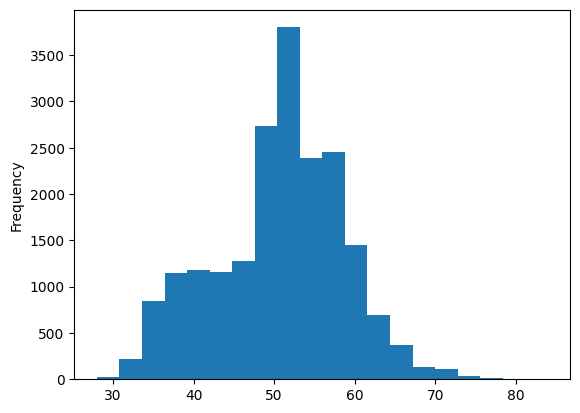

In [106]:
data_analysis_final["RiskScore"].plot.hist(bins=20)

In [107]:
data_analysis_final["RiskCategory"] = pd.cut(data_analysis_final["RiskScore"], bins=5, labels=[0, 1, 2, 3, 4])

In [108]:
data_analysis_final.drop(columns=["RiskScore"], inplace=True)

In [109]:
data_analysis_final.head()

,BankruptcyHistory,LoanAmountToIncome,PreviousLoanDefaults,CreditScore,TotalLiabilitiesToIncome,Experience,Age,EducationLevel,NetWorthToIncome,EmploymentStatus_Unemployed,RiskCategory
0,0,0.329228,0,617,0.480199,1.833333,45,3,3.177331,0,1
1,0,0.655897,0,628,0.241633,1.250000,38,2,1.098215,0,2
2,0,0.432841,0,570,3.164571,2.166667,47,1,0.127812,0,2
3,0,0.548579,0,545,0.077731,2.833333,58,0,1.439581,0,2
4,0,0.088937,0,594,0.167396,1.416667,37,2,2.198433,0,0


In [110]:
from sklearn.model_selection import train_test_split

In [111]:
X = data_analysis_final.drop(columns=["RiskCategory"])
y = data_analysis_final["RiskCategory"]

In [112]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [114]:
from sklearn.ensemble import RandomForestClassifier

In [117]:
rf = RandomForestClassifier()

In [118]:
from sklearn.model_selection import GridSearchCV

In [119]:
cv = GridSearchCV(estimator=rf, param_grid={"n_estimators": [50, 100, 200], "max_depth": [5, 10, 20], "min_samples_split": [2, 5, 10]}, cv=5)

In [120]:
cv.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 10, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [50, 100, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the

In [121]:
rf_model = cv.best_estimator_

In [ ]:
from sklearn.metrics import f1_score, classification_report

In [123]:
f1_score(y_test, rf_model.predict(X_test), average="weighted")

0.6349791008276119

In [124]:
print(classification_report(y_test, rf_model.predict(X_test)))

              precision    recall  f1-score   support

           0       0.64      0.36      0.46       492
           1       0.54      0.54      0.54      1300
           2       0.70      0.82      0.75      1942
           3       0.77      0.50      0.60       256
           4       0.00      0.00      0.00        10

    accuracy                           0.65      4000
   macro avg       0.53      0.44      0.47      4000
weighted avg       0.64      0.65      0.63      4000



d:\personal\Personal_Finance_Helper_Bot\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\personal\Personal_Finance_Helper_Bot\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
d:\personal\Personal_Finance_Helper_Bot\venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capi

In [126]:
feat_impt = pd.DataFrame({"Feature": X.columns, "Importance": rf_model.feature_importances_}).sort_values(by="Importance", ascending=False)

In [127]:
feat_impt.head()

,Feature,Importance
1,LoanAmountToIncome,0.308509
8,NetWorthToIncome,0.147468
3,CreditScore,0.144320
0,BankruptcyHistory,0.133798
4,TotalLiabilitiesToIncome,0.097168


In [128]:
feat_impt.to_csv("feature_importance.csv", index=False)

In [129]:
import dill 

with open("rf_model.pkl", "wb") as f:
    dill.dump(rf_model, f)

In [131]:
from lime import lime_tabular

explainer = lime_tabular.LimeTabularExplainer(X_train.values, feature_names=X_train.columns, class_names=[0, 1, 2, 3, 4], mode="classification")

In [132]:
explanation = explainer.explain_instance(X_test.iloc[0].values, rf_model.predict_proba, num_features=10)

d:\personal\Personal_Finance_Helper_Bot\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [134]:
print(explanation.as_list())

[('BankruptcyHistory <= 0.00', 0.24676066667116991), ('PreviousLoanDefaults <= 0.00', 0.16369527661499694), ('TotalLiabilitiesToIncome <= 0.20', 0.053751492652109094), ('EmploymentStatus_Unemployed <= 0.00', 0.051512264063902656), ('NetWorthToIncome <= 0.18', -0.03853289581071658), ('32.00 < Age <= 40.00', -0.009308257394168198), ('EducationLevel <= 0.00', -0.007998698218854565), ('0.26 < LoanAmountToIncome <= 0.46', -0.007779226121905628), ('579.00 < CreditScore <= 609.00', -0.004185199139584506), ('0.75 < Experience <= 1.42', -0.00018383315913507008)]


In [135]:
with open("lime_explainer.pkl", "wb") as f:
    dill.dump(explainer, f)